<a href="https://colab.research.google.com/github/iamkzntsv/self-supervised-learning-mri/blob/master/VAE_MNIST_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.distributions as dist
from torch.nn import functional as F
import matplotlib.pyplot as plt

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
!pip install torch-summary

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [4]:
from torchsummary import summary

# Encoder

In [5]:
latent_dim = 5

In [6]:
class Encoder(nn.Module):

    def __init__(self, in_channels, latent_dim, dropout_rate):
        """
        :param in_channels: number of channels in the input shape
        :param latent_dim: size of latent space (int)
        :param dropout_rate: dropout probability (float)
        """
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        # Dimensions of hidden layers
        filters = [32, 64, 128, 128]

        # Build the encoder
        layers = []
        for f in filters:
            layers.append(
                nn.Sequential(
                    nn.Conv2d(in_channels, f, kernel_size=5, stride=2, padding=2),
                    nn.BatchNorm2d(f),
                    nn.LeakyReLU()
                )
            )
            in_channels = f

        layers.append(
            nn.Sequential(
                nn.Conv2d(in_channels, 16, kernel_size=1, stride=1),
                nn.LeakyReLU(),
                nn.Dropout(dropout_rate),
            )
        )

        self.encoder = nn.Sequential(*layers)
        self.final_layer = nn.Sequential(
            nn.Linear(1024, 1024)
        )
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_var = nn.Linear(1024, latent_dim)

    def encode(self, input):
        """

        :param input:
        :return:
        """
        # Compute encoder output
        out = self.encoder(input)
        out = torch.flatten(out, start_dim=1)
        out = self.final_layer(out)
        mu = self.fc_mu(out)
        log_var = self.fc_var(out)

        return [mu, log_var]

    def reparameterize(self, mu, log_var):
        """
        Reparameterization trick
        :param mu:
        :param log_var:
        :return:
        """
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)

        return mu + std * eps

    def forward(self, X):
        """
        Sample z from a distribution q
        :param X: input of shape (B, C, H, W)
        :return: 
          sample from the distribution q_zx
          a list containing mu and sigma vectors
        """
        mu, log_var = self.encode(X)
        z = self.reparameterize(mu, log_var)

        return [z, mu, log_var]

In [7]:
enc = Encoder(1, latent_dim, 0.2) # num_channels, latent_dim, dropout_prob
summary(enc, (1, 128, 128))

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 8, 8]            --
|    └─Sequential: 2-1                   [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 32, 64, 64]          832
|    |    └─BatchNorm2d: 3-2             [-1, 32, 64, 64]          64
|    |    └─LeakyReLU: 3-3               [-1, 32, 64, 64]          --
|    └─Sequential: 2-2                   [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 32, 32]          51,264
|    |    └─BatchNorm2d: 3-5             [-1, 64, 32, 32]          128
|    |    └─LeakyReLU: 3-6               [-1, 64, 32, 32]          --
|    └─Sequential: 2-3                   [-1, 128, 16, 16]         --
|    |    └─Conv2d: 3-7                  [-1, 128, 16, 16]         204,928
|    |    └─BatchNorm2d: 3-8             [-1, 128, 16, 16]         256
|    |    └─LeakyReLU: 3-9               [-1, 128, 16, 16]         --
|  

Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 8, 8]            --
|    └─Sequential: 2-1                   [-1, 32, 64, 64]          --
|    |    └─Conv2d: 3-1                  [-1, 32, 64, 64]          832
|    |    └─BatchNorm2d: 3-2             [-1, 32, 64, 64]          64
|    |    └─LeakyReLU: 3-3               [-1, 32, 64, 64]          --
|    └─Sequential: 2-2                   [-1, 64, 32, 32]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 32, 32]          51,264
|    |    └─BatchNorm2d: 3-5             [-1, 64, 32, 32]          128
|    |    └─LeakyReLU: 3-6               [-1, 64, 32, 32]          --
|    └─Sequential: 2-3                   [-1, 128, 16, 16]         --
|    |    └─Conv2d: 3-7                  [-1, 128, 16, 16]         204,928
|    |    └─BatchNorm2d: 3-8             [-1, 128, 16, 16]         256
|    |    └─LeakyReLU: 3-9               [-1, 128, 16, 16]         --
|  

# Decoder

In [8]:
class Decoder(nn.Module):

    def __init__(self, out_channels, latent_dim):
        super(Decoder, self).__init__()
        self.out_channels = out_channels
        self.latent_dim = latent_dim

        # Dimensions of hidden layers
        filters = [128, 128, 64, 32, 32]

        # Build the decoder
        self.decoder_input = nn.Linear(latent_dim, 1024)

        layers = []
        layers.append(
            nn.Sequential(
                    nn.ConvTranspose2d(16, 128, kernel_size=1, stride=1),
                    nn.BatchNorm2d(128),
                    nn.LeakyReLU()
            )
        )
        
        for i in range(len(filters) - 1):
            layers.append(
                nn.Sequential(
                    nn.ConvTranspose2d(filters[i], filters[i+1], kernel_size=5, stride=2, padding=2, output_padding=1),
                    nn.BatchNorm2d(filters[i + 1]),
                    nn.LeakyReLU()
                )
            )

        self.final_layer = (
                nn.Sequential(
                    nn.Conv2d(filters[-1], out_channels, kernel_size=1, stride=1),
                    nn.LeakyReLU()
                )
            )

        self.decoder = nn.Sequential(*layers)

    def forward(self, z):
        """
        Reconstruct the image from the latent code
        :param z: latent code
        :return:
        """
        result = self.decoder_input(z)
        result = result.view(-1, 16, 8, 8)
        result = self.decoder(result)
        x_hat = self.final_layer(result)

        return x_hat

In [9]:
dec = Decoder(1, latent_dim) # out_channels, latent_dim
summary(dec, (1, latent_dim))

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 1024]             6,144
├─Sequential: 1-2                        [-1, 32, 128, 128]        --
|    └─Sequential: 2-1                   [-1, 128, 8, 8]           --
|    |    └─ConvTranspose2d: 3-1         [-1, 128, 8, 8]           2,176
|    |    └─BatchNorm2d: 3-2             [-1, 128, 8, 8]           256
|    |    └─LeakyReLU: 3-3               [-1, 128, 8, 8]           --
|    └─Sequential: 2-2                   [-1, 128, 16, 16]         --
|    |    └─ConvTranspose2d: 3-4         [-1, 128, 16, 16]         409,728
|    |    └─BatchNorm2d: 3-5             [-1, 128, 16, 16]         256
|    |    └─LeakyReLU: 3-6               [-1, 128, 16, 16]         --
|    └─Sequential: 2-3                   [-1, 64, 32, 32]          --
|    |    └─ConvTranspose2d: 3-7         [-1, 64, 32, 32]          204,864
|    |    └─BatchNorm2d: 3-8             [-1, 64, 32, 32]          

Layer (type:depth-idx)                   Output Shape              Param #
├─Linear: 1-1                            [-1, 1, 1024]             6,144
├─Sequential: 1-2                        [-1, 32, 128, 128]        --
|    └─Sequential: 2-1                   [-1, 128, 8, 8]           --
|    |    └─ConvTranspose2d: 3-1         [-1, 128, 8, 8]           2,176
|    |    └─BatchNorm2d: 3-2             [-1, 128, 8, 8]           256
|    |    └─LeakyReLU: 3-3               [-1, 128, 8, 8]           --
|    └─Sequential: 2-2                   [-1, 128, 16, 16]         --
|    |    └─ConvTranspose2d: 3-4         [-1, 128, 16, 16]         409,728
|    |    └─BatchNorm2d: 3-5             [-1, 128, 16, 16]         256
|    |    └─LeakyReLU: 3-6               [-1, 128, 16, 16]         --
|    └─Sequential: 2-3                   [-1, 64, 32, 32]          --
|    |    └─ConvTranspose2d: 3-7         [-1, 64, 32, 32]          204,864
|    |    └─BatchNorm2d: 3-8             [-1, 64, 32, 32]          

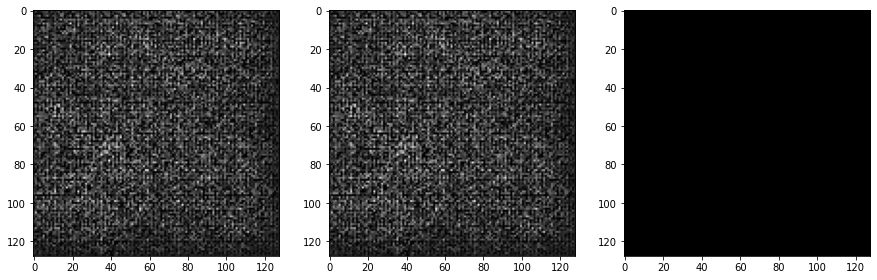

In [10]:
z = torch.randn(1, latent_dim)
z2 = torch.clone(z)
x_hat = dec(z).squeeze().detach().numpy()
x_hat2 = dec(z2).squeeze().detach().numpy()

plt.rcParams["figure.figsize"] = (15,5)
plt.subplot(131)
plt.imshow(x_hat, cmap='gray')
plt.subplot(132)
plt.imshow(x_hat2, cmap='gray')
plt.subplot(133)
plt.imshow(x_hat2 - x_hat, cmap='gray')
plt.show()

# VAE

In [11]:
class VAE(nn.Module):

    def __init__(self, in_channels, latent_dim, out_channels, dropout_rate):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(in_channels, latent_dim, dropout_rate)
        self.decoder = Decoder(out_channels, latent_dim)

    def encode(self, X):
        z,_,_ = self.encoder(X)
        return z

    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, X):
        z, mu, log_var = self.encoder(X)
        x_hat = self.decoder(z)
        return x_hat, mu, log_var

In [12]:
vae = VAE(1, 2, 1, 0.2)
X = torch.rand(10, 1, 128, 128) # (B, C, H, W)

In [13]:
# Get sample from the latent distribution
z = vae.encode(X)
print(f"Z size: {z.size()}")

# Run the through the decoder
x_hat = vae.decode(z)
print(f"x_hat size: {x_hat.size()}")

Z size: torch.Size([10, 2])
x_hat size: torch.Size([10, 1, 128, 128])


# Loss

## KL

In [14]:
def kl_divergence(qzx):
    """
    Compute the KL divergence between given distribution qzx and standard normal distribution
    :param qzx: distribution produced by the encoder, tuple where each item is of shape (B, latent_dim)
    :return: KL divergence between q(z|x) and p(z), where p(z)~N(0,I).
    """
    mu, var = qzx[0], torch.exp(qzx[1])

    # Compute KL divergence
    kl = var + torch.square(mu) - 1 - torch.log(var)

    return 0.5 * kl.sum(-1)

In [15]:
def kl_divergence(mu, log_var):
    """
    Compute the KL divergence between given distribution qzx and standard normal distribution
    :param qzx: distribution produced by the encoder, tuple where each item is of shape (B, latent_dim)
    :return: KL divergence between q(z|x) and p(z), where p(z)~N(0,I).
    """

    kl = torch.exp(log_var) + torch.square(mu) - 1 - log_var

    return 0.5 * torch.sum(kl, -1)

In [16]:
# Test case 1: Standard Normal distribution
mu1 = torch.unsqueeze(torch.zeros(5), 0)
log_var1 = torch.log(torch.unsqueeze(torch.ones(5), 0))

# Test case 2: Normal distribution with randn noise 
mu2 = torch.unsqueeze(torch.zeros(5), 0)
log_var2 = torch.log(torch.unsqueeze(torch.ones(5), 0)) + torch.randn(1,5)

# Test case 2: Normal distribution with shifted mean and randn noise
mu3 = torch.unsqueeze(torch.zeros(5), 0) + 2
log_var3 = torch.log(torch.unsqueeze(torch.ones(5), 0)) + torch.randn(1,5)

print(kl_divergence(mu1, log_var1))
print(kl_divergence(mu2, log_var2))
print(kl_divergence(mu3, log_var3))

tensor([0.])
tensor([1.4081])
tensor([11.4335])


## Reconstruction

Normal Distribution pdf:

$$p(x | \mu, \sigma) = \frac{1}{\sigma \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{(x - \mu)^2}{\sigma^2}}\bigg)$$

Likelihood for $Y = {y_{1}, y_{1},... y_{n}}$.

\begin{align}
\mathcal{L}(\theta|Y) 
&= \Pi_{i=1}^n \Bigl[\frac{1}{\sigma_{\theta}(x_{i}) \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}}\bigg)\Bigr] \\
&= \sum_{i=1}^n log \Bigl[\frac{1}{\sigma_{\theta}(x_{i}) \sqrt{2 \pi}} \exp{\bigg(-\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}}\bigg) \Bigr] \\
&= \sum_{i=1}^n \Bigl[-\frac{1}{2}\log2\pi- \log\sigma_{\theta}(x_{i}) -\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
\end{align}

Where:

$\qquad x_{i}$ is the input data.

$\qquad y_{i}$ is the true value of the dependent variable.

$\qquad \mu_{\theta}(x_{i})$ is the output of the model.

$\qquad \sigma(x_{i})$ is the standart deviation of the data sample.

Optimal parameters are then given by:

\begin{align}
\underset{\theta}{\mathrm{argmax}}\ \mathcal{L}(\theta|Y) 
&= \underset{\theta}{\mathrm{argmax}}\ \sum_{i=1}^n \Bigl[-\frac{1}{2}\log2\pi- \log \sigma_{\theta}(x_{i}) -\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
&= \underset{\theta}{\mathrm{argmin}}\ \sum_{i=1}^n \Bigl[\log\sigma_{\theta}(x_{i}) +\frac{1}{2}\frac{\bigl(y_i - \mu_{\theta}(x_i)\bigr)^2}{\sigma_{\theta}(x_{i})^2}\Bigr] \\
\end{align}


In [17]:
def reconstruction_loss(loss, X, X_hat, scale_var=0.001):
    """
    Compute the reconstruction loss
    :param X:
    :param X_hat:
    :return:
    """
    var = torch.ones(X.size())*scale_var # multiply by a small num
 
    return loss(X, X_hat, var)

criterion = nn.GaussianNLLLoss()

In [18]:
# Same tensor
X = torch.randn(1, 3, 100, 100)
X_hat = X.clone().detach()

loss = reconstruction_loss(criterion, X, X_hat)
print(loss)

tensor(-3.4539)


In [19]:
# Different tensors
X = torch.randn(5, 3, 100, 100)
X_hat = torch.randn(5, 3, 100, 100)

loss = reconstruction_loss(criterion, X, X_hat)
print(loss)

tensor(995.1130)


In [20]:
def loss_test():
    var = torch.ones(X.size())
    loss = torch.multiply(1/2, (torch.log(var) + torch.square(X-X_hat)/var))
    print(loss.size())
    
    return torch.mean(loss).size()

loss_test()

torch.Size([5, 3, 100, 100])


torch.Size([])

## Total Loss

In [103]:
class Loss_VAE(nn.Module):

    def __init__(self, vae):
        super(Loss_VAE, self).__init__()
        self.vae = vae
        self.latent_dim = vae.latent_dim

    def forward(self, X):
        X_hat, mu, log_var  = self.vae(X)
        loss = self.kl_divergence(mu, log_var) + self.reconstruction_loss(X, X_hat)
        return loss
    

    def kl_divergence(self, mu, log_var):
        """
        Compute the KL divergence between given distribution q(z|x) and standard normal distribution
        :param mu: mean vector produced by the encoder, tensor of shape (B, latent_dim)
        :param log_var: log sigma vector produced by the encoder, tensor of shape (B, latent_dim)
        :return: KL divergence between q(z|x) and p(z), where p(z)~N(0,I).
        """
        kl = 0.5 * torch.sum((torch.exp(log_var) + torch.square(mu) - 1 - log_var), -1)

        return torch.mean(kl)

    def reconstruction_loss(self, X, X_hat, scale_var=0.001):
        """
        Compute the reconstruction loss
        :param X: input data
        :param X_hat: output of the decoder
        :param scale_var: a small number for scaling variance
        :return:
        """
        criterion = nn.GaussianNLLLoss(reduction='mean')
        var = torch.ones(X.size())*scale_var

        return criterion(X, X_hat, var)


In [100]:
vae = VAE(1, 2, 1, 0.2)

loss_function = Loss_VAE(vae)
mu1 = torch.zeros(10,2)
log_sigma1 = torch.log(torch.ones(10,2))
l1 = loss_function.kl_divergence(mu1, log_sigma1)
print(l1)

tensor(0.)


In [98]:
X = torch.rand(10, 1, 128, 128) # (B, C, H, W)
X_hat = torch.rand(10, 1, 128, 128) + torch.randn(10, 1, 128, 128)
l2 = loss_function.reconstruction_loss(X, X_hat)
print(l2)

tensor(579.7265)


In [101]:
X = torch.rand(10, 1, 128, 128) # (B, C, H, W)
X_hat = torch.rand(10, 1, 128, 128) + torch.randn(10, 1, 128, 128)

loss_function = Loss_VAE(vae)
loss = loss_function(X)
loss

tensor(0.0136, grad_fn=<MeanBackward0>)
tensor(155.1569, grad_fn=<MeanBackward0>)


tensor(155.1705, grad_fn=<AddBackward0>)

# Training

In [115]:
from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.utils import make_grid
from torchvision.transforms import Compose
from torchvision.transforms import ToTensor, Resize
from torch.utils.data import DataLoader
import itertools

In [116]:
transform = Compose([ToTensor(), Resize((128, 128))])
mnist_dataset = MNIST(root="data/", download=True, transform=transform)
train_loader = DataLoader(mnist_dataset, batch_size=32, shuffle=True)

In [117]:
num_in, num_out = 1, 1
latent_dim = 2

vae = VAE(num_in, latent_dim, num_out, 0.2)

opt_vae = torch.optim.Adam(itertools.chain(enc.parameters(), dec.parameters()), lr = 7.5e-4)
loss_function = Loss_VAE(vae)

In [119]:
epochs = 10
losses = []
for epoch in range(epochs):
    train_loss = 0.0
    for (X,_) in train_loader:
        X = X.to(device)
        opt_vae.zero_grad()
        loss = loss_function(X)
        loss.backward()
        opt_vae.step()
        train_loss += loss.item() * X.shape[0] / len(mnist_dataset)


KeyboardInterrupt: ignored